Hugo Tanaka

CSCI 611 

Assignment 2

2026 Feburary 17th

I have used these followings:
- Python 3.10
- Venv to setup the environment.
- Packages installed are in the requirement.txt. Please run `pip install -r requirements.txt` to install the packages.

# Convolutional Neural Networks - Build Model
---
In this notebook, we build and train a **CNN** to classify images from the CIFAR-10 database. 
* The code provided here are **almost** working. You are required to build up a CNN model and train it.
* Make sure you covered implementations of the **TODO**s in this notebook

The images in this database are small color images that fall into one of ten classes; some example images are pictured below.

<img src='cifar_data.png' width=50% height=50% />

### Optional: Use [CUDA](http://pytorch.org/docs/stable/cuda.html) if Available

Since these are color (32x32x3) images, it may prove useful to speed up your training time by using a GPU. CUDA is a parallel computing platform and CUDA Tensors are the same as typical Tensors, but they utilize GPU's for effcient parallel computation.

In [4]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is not available.  Training on CPU ...


## Load the [Data](http://pytorch.org/docs/stable/torchvision/datasets.html)
---
Downloading may take a minute. We load in the training and test data, split the training data into a training and validation set, then create DataLoaders for each of these sets of data.

In [5]:
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20
# percentage of training set to use as validation
valid_size = 0.2

# convert data to a normalized torch.FloatTensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

# choose the training and test datasets
train_data = datasets.CIFAR10('data', train=True,
                              download=True, transform=transform)
test_data = datasets.CIFAR10('data', train=False,
                             download=True, transform=transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

# specify the image classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

### Visualize a Batch of Training Data

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

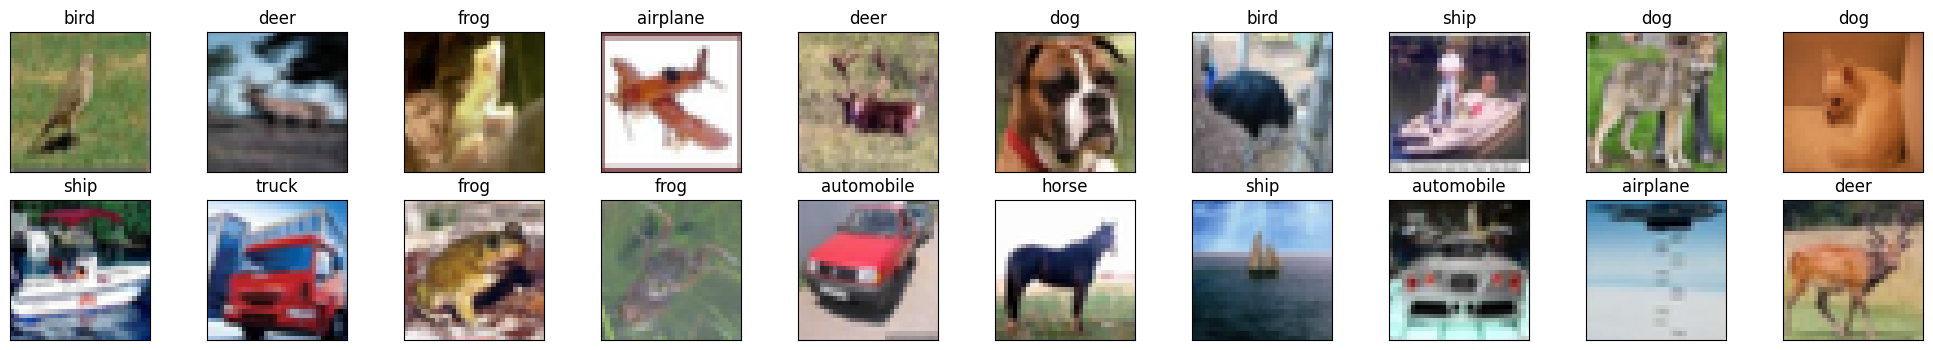

In [7]:
# obtain one batch of training images
dataiter = iter(train_loader)
#images, labels = dataiter.next() #python, torchvision version match issue
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
# display 20 images
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

### View an Image in More Detail

Here, we look at the normalized red, green, and blue (RGB) color channels as three separate, grayscale intensity images.

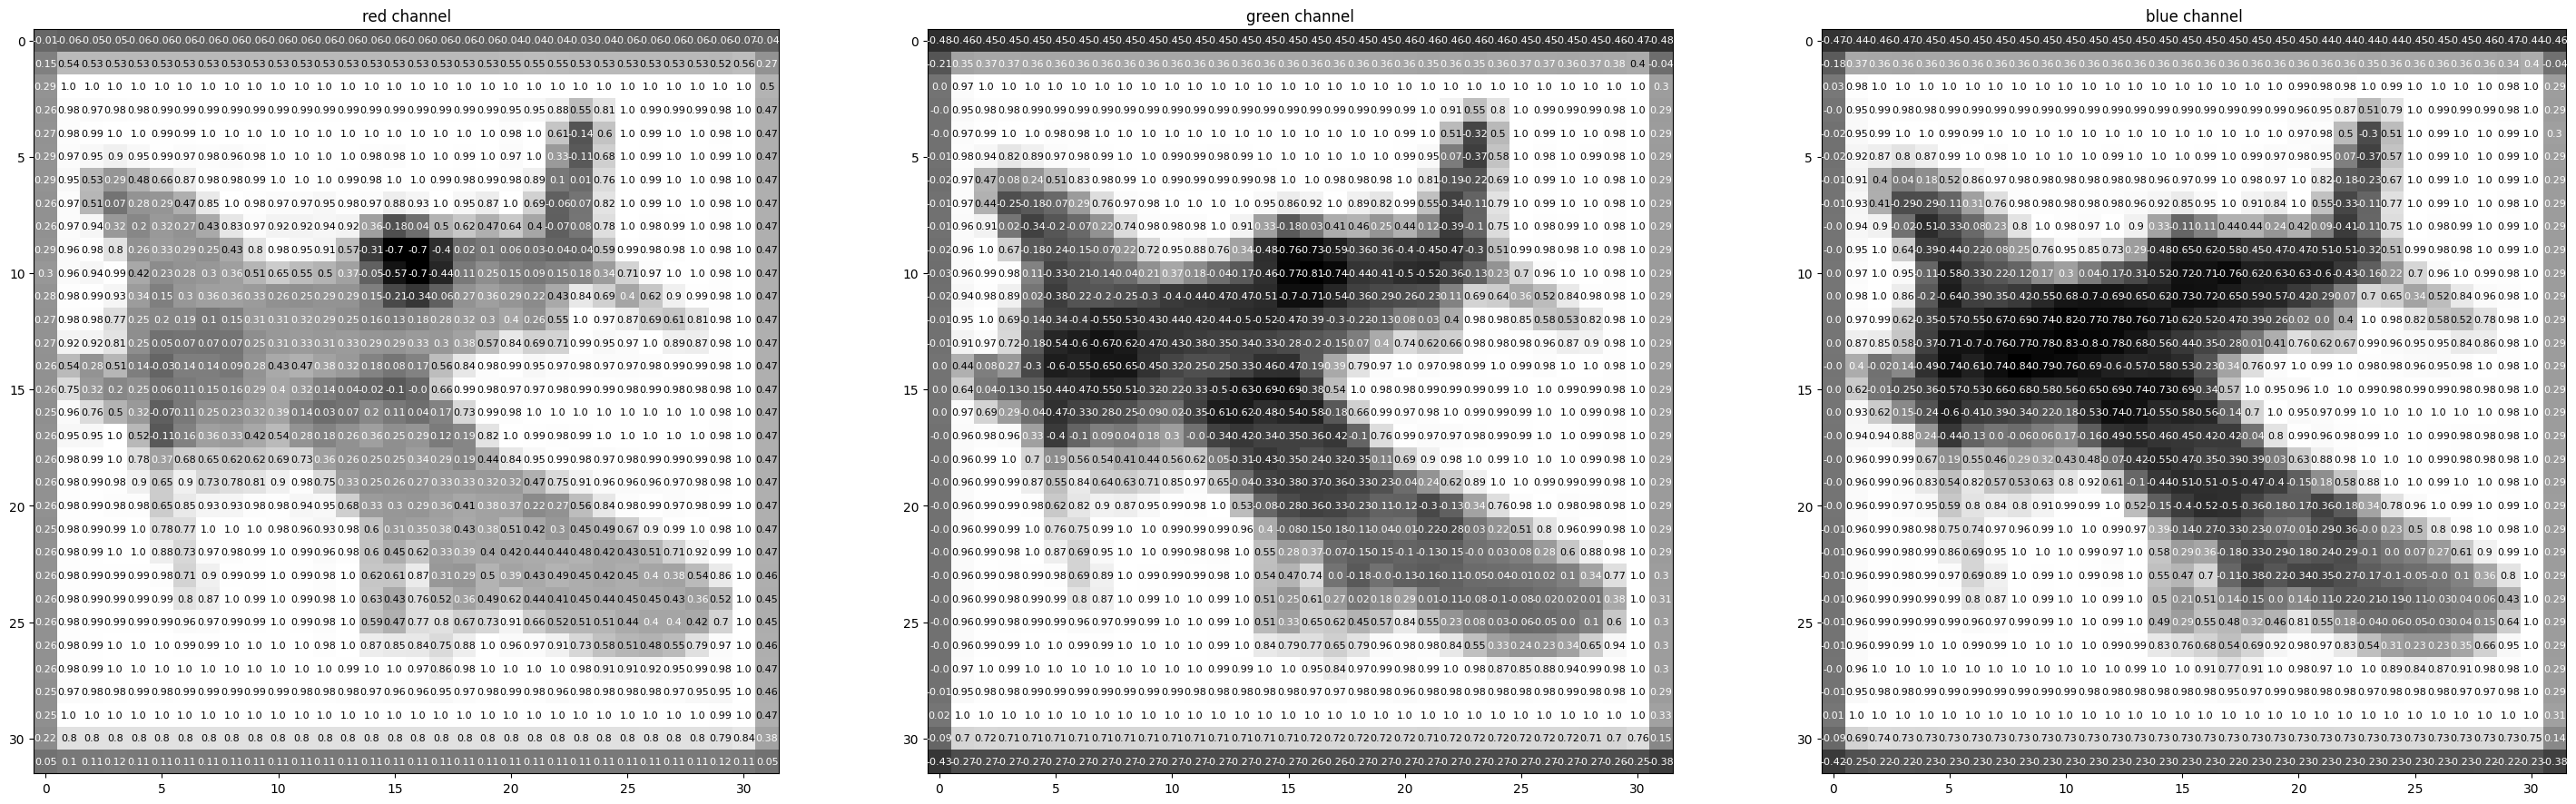

In [8]:
rgb_img = np.squeeze(images[3])
channels = ['red channel', 'green channel', 'blue channel']

fig = plt.figure(figsize = (36, 36)) 
for idx in np.arange(rgb_img.shape[0]):
    ax = fig.add_subplot(1, 3, idx + 1)
    img = rgb_img[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(channels[idx])
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            val = round(img[x][y],2) if img[x][y] !=0 else 0
            ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center', size=8,
                    color='white' if img[x][y]<thresh else 'black')

## **TODO**: Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)
---
Build up your own Convolutional Neural Network using Pytorch API:
- nn.Conv2d(): for convolution
- nn.MaxPool2d(): for maxpooling (spatial resolution reduction)
- nn.Linear(): for last 1 or 2 layers of fully connected layer before the output layer.
- nn.Dropout(): optional, [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) can be used to avoid overfitting.
- F.relu(): Use ReLU as the activation function for all the hidden layers

The following is a skeleton example that's not completely working. 

In [9]:
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        # DONE: Build multiple convolutional layers (sees 32x32x3 image tensor in the first hidden layer)
        # for example, conv1, conv2 and conv3

        #conv1, 16 output layers, balanced:
        # 32x32x3 -> 32x32x16
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)

        #conv2, 32 layers
        # 16x16x16 -> 16x16x32
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
    
        #conv3, 64 layers
        # 8x8x32 -> 8x8x64
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        
        # max pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # DONE: Build some linear layers (fully connected)
        # for example, fc1 and fc2
        
        # fc1, 64 * 4 * 4 = 1024
        self.fc1 = nn.Linear(1024, 512)

        # fc2, 10, because 10 "answers".
        self.fc2 = nn.Linear(512, 10)

        # DONE: dropout layer (p=0.25, you can adjust)
        # example self.dropout = nn.Dropout(0.25)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # add sequence of convolutional and max pooling layers
        # assume we have 3 convolutional layers (used to be 2 in orignal)
        # defined above
        # and we do a maxpooling after each conv layer
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # TODO: flatten x at this point to get it ready to feed into the fully connected layer(s)
        # Can use this but need to figure out the actual value for a, b and c
        # 1024 from final size after conv3
        x = x.view(-1, 1024)

        # optional add dropout layer
        x = self.dropout(x)
        
        # add 1st hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        # optional add dropout layer
        x = self.dropout(x)
        # add 2nd hidden layer, with relu activation function
        x = self.fc2(x)
        return x

# create a complete CNN
# Made two for SGD and ADAM
model_sgd = Net()
model_adam = Net()
print(model_sgd)
print(model_adam)

# move tensors to GPU if CUDA is available
if train_on_gpu:
    model_sgd.cuda()
    model_adam.cuda()

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)
Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


### Specify [Loss Function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [Optimizer](http://pytorch.org/docs/stable/optim.html)
---
Decide on a loss and optimization function that is best suited for this classification task. The linked code examples from above, may be a good starting point; [this PyTorch classification example](https://github.com/pytorch/tutorials/blob/master/beginner_source/blitz/cifar10_tutorial.py) Pay close attention to the value for **learning rate** as this value determines how your model converges to a small error.

The following is working code, but you can make your own adjustments.

**TODO**: try to compare with ADAM optimizer

In [10]:
import torch.optim as optim

# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# TODO, compare with optimizer ADAM 
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

# ^ Note to myself, ADAM has slower learning rate than SGD, 
# so lr value is lower than SGD

## Train the Network
---
Remember to look at how the training and validation loss decreases over time; if the validation loss ever increases it indicates possible overfitting.

The following is working code, but you are encouraged to make your own adjustments and enhance the implementation.

EDIT: I made a copy of the two same functions for SGD and ADAM Optimizer, I will use this to test out which is better.

In [11]:
# This is for SGD

# number of epochs to train the model, you decide the number
n_epochs = 5

valid_loss_min = np.Inf # track change in validation loss

for epoch in range(1, n_epochs+1):

    # keep track of training and validation loss
    train_loss = 0.0
    valid_loss = 0.0
    
    ###################
    # train the model #
    ###################
    model_sgd.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # clear the gradients of all optimized variables
        optimizer_sgd.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model_sgd(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer_sgd.step()
        # update training loss
        train_loss += loss.item()*data.size(0)
        
    ######################    
    # validate the model #
    ######################
    model_sgd.eval()
    for batch_idx, (data, target) in enumerate(valid_loader):
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model_sgd(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update average validation loss 
        valid_loss += loss.item()*data.size(0)
    
    # calculate average losses
    train_loss = train_loss/len(train_loader.sampler)
    valid_loss = valid_loss/len(valid_loader.sampler)
        
    # print training/validation statistics 
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model_sgd.state_dict(), 'model_trained_sgd.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 2.130164 	Validation Loss: 1.799416
Validation loss decreased (inf --> 1.799416).  Saving model ...
Epoch: 2 	Training Loss: 1.678349 	Validation Loss: 1.512869
Validation loss decreased (1.799416 --> 1.512869).  Saving model ...
Epoch: 3 	Training Loss: 1.486460 	Validation Loss: 1.389833
Validation loss decreased (1.512869 --> 1.389833).  Saving model ...
Epoch: 4 	Training Loss: 1.366250 	Validation Loss: 1.259230
Validation loss decreased (1.389833 --> 1.259230).  Saving model ...
Epoch: 5 	Training Loss: 1.270726 	Validation Loss: 1.210466
Validation loss decreased (1.259230 --> 1.210466).  Saving model ...


In [12]:
# This is for ADAM

# number of epochs to train the model, you decide the number
n_epochs = 5

valid_loss_min = np.Inf # track change in validation loss

for epoch in range(1, n_epochs+1):

    # keep track of training and validation loss
    train_loss = 0.0
    valid_loss = 0.0
    
    ###################
    # train the model #
    ###################
    model_adam.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # clear the gradients of all optimized variables
        optimizer_adam.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model_adam(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer_adam.step()
        # update training loss
        train_loss += loss.item()*data.size(0)
        
    ######################    
    # validate the model #
    ######################
    model_adam.eval()
    for batch_idx, (data, target) in enumerate(valid_loader):
        # move tensors to GPU if CUDA model_adam = model_sgdis available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model_adam(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update average validation loss 
        valid_loss += loss.item()*data.size(0)
    
    # calculate average losses
    train_loss = train_loss/len(train_loader.sampler)
    valid_loss = valid_loss/len(valid_loader.sampler)
        
    # print training/validation statistics 
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model_adam.state_dict(), 'model_trained_adam.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 1.472285 	Validation Loss: 1.174674
Validation loss decreased (inf --> 1.174674).  Saving model ...
Epoch: 2 	Training Loss: 1.114017 	Validation Loss: 0.994490
Validation loss decreased (1.174674 --> 0.994490).  Saving model ...
Epoch: 3 	Training Loss: 0.960224 	Validation Loss: 0.884515
Validation loss decreased (0.994490 --> 0.884515).  Saving model ...
Epoch: 4 	Training Loss: 0.860349 	Validation Loss: 0.871819
Validation loss decreased (0.884515 --> 0.871819).  Saving model ...
Epoch: 5 	Training Loss: 0.787198 	Validation Loss: 0.895472


###  Load the Model with the Lowest Validation Loss
This is the model we will use for testing, which is the model we saved in the last step

In [13]:
model_sgd.load_state_dict(torch.load('model_trained_sgd.pt'))
model_adam.load_state_dict(torch.load('model_trained_adam.pt'))

<All keys matched successfully>

## Test the Trained Network
---
Test your trained model on previously unseen data! Remember we have downloaded `train_data` and `test_data`. We will use `test_data` through `test_loader`.

A "good" result will be a CNN that gets around 70% (or more, try your best!) accuracy on these test images.

The following is working code, but you are encouraged to make your own adjustments and enhance the implementation.

In [14]:
# track test loss, SGD
test_loss_sgd = 0.0
class_correct_sgd = list(0. for i in range(10))
class_total_sgd = list(0. for i in range(10))

model_sgd.eval()
# iterate over test data
for batch_idx, (data, target) in enumerate(test_loader):
    # move tensors to GPU if CUDA is available
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model_sgd(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update test loss 
    test_loss_sgd += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)    
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct_sgd[label] += correct[i].item()
        class_total_sgd[label] += 1

# average test loss
test_loss_sgd = test_loss_sgd/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss_sgd))

for i in range(10):
    if class_total_sgd[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct_sgd[i] / class_total_sgd[i],
            np.sum(class_correct_sgd[i]), np.sum(class_total_sgd[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct_sgd) / np.sum(class_total_sgd),
    np.sum(class_correct_sgd), np.sum(class_total_sgd)))

Test Loss: 1.208573

Test Accuracy of airplane: 58% (589/1000)
Test Accuracy of automobile: 49% (494/1000)
Test Accuracy of  bird: 35% (358/1000)
Test Accuracy of   cat: 29% (293/1000)
Test Accuracy of  deer: 50% (509/1000)
Test Accuracy of   dog: 60% (601/1000)
Test Accuracy of  frog: 59% (597/1000)
Test Accuracy of horse: 72% (727/1000)
Test Accuracy of  ship: 73% (730/1000)
Test Accuracy of truck: 75% (754/1000)

Test Accuracy (Overall): 56% (5652/10000)


In [15]:
# track test loss, ADAM
test_loss_adam = 0.0
class_correct_adam = list(0. for i in range(10))
class_total_adam = list(0. for i in range(10))

model_adam.eval()
# iterate over test data
for batch_idx, (data, target) in enumerate(test_loader):
    # move tensors to GPU if CUDA is available
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model_adam(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update test loss 
    test_loss_adam += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)    
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct_adam[label] += correct[i].item()
        class_total_adam[label] += 1

# average test loss
test_loss_adam = test_loss_adam/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss_adam))

for i in range(10):
    if class_total_adam[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct_adam[i] / class_total_adam[i],
            np.sum(class_correct_adam[i]), np.sum(class_total_adam[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct_adam) / np.sum(class_total_adam),
    np.sum(class_correct_adam), np.sum(class_total_adam)))

Test Loss: 0.872873

Test Accuracy of airplane: 75% (757/1000)
Test Accuracy of automobile: 81% (816/1000)
Test Accuracy of  bird: 62% (627/1000)
Test Accuracy of   cat: 47% (476/1000)
Test Accuracy of  deer: 52% (523/1000)
Test Accuracy of   dog: 61% (614/1000)
Test Accuracy of  frog: 88% (881/1000)
Test Accuracy of horse: 67% (671/1000)
Test Accuracy of  ship: 77% (778/1000)
Test Accuracy of truck: 80% (809/1000)

Test Accuracy (Overall): 69% (6952/10000)


### Visualize Sample Test Results

The following is working code, but you are encouraged to make your own adjustments and enhance the visualization.

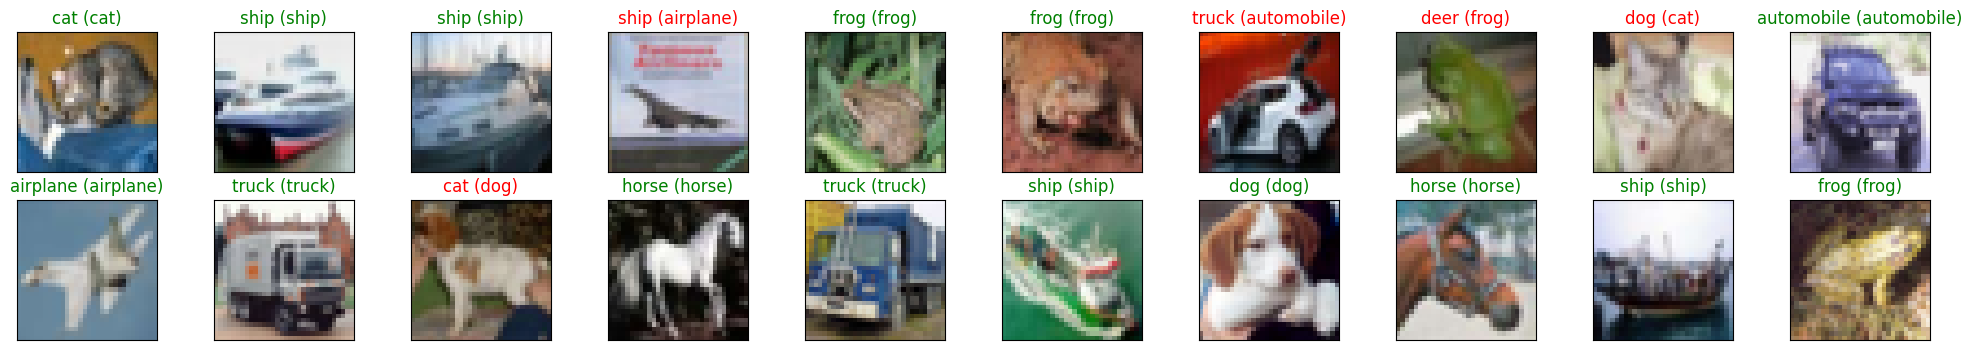

In [16]:
# obtain one batch of test images, SGD
dataiter = iter(test_loader)
images, labels = next(dataiter)
images.numpy()

# move model inputs to cuda, if GPU available
if train_on_gpu:
    images = images.cuda()

# get sample outputs
output = model_sgd(images)
# convert output probabilities to predicted class
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx].item() else "red"))

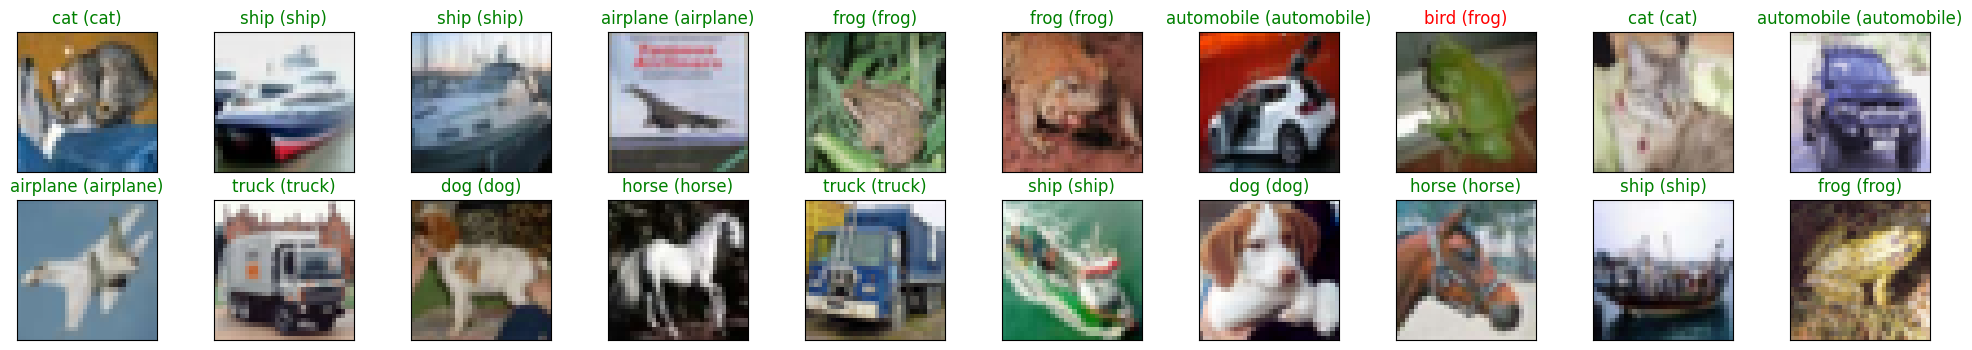

In [17]:
# obtain one batch of test images, ADAM
dataiter = iter(test_loader)
images, labels = next(dataiter)
images.numpy()

# move model inputs to cuda, if GPU available
if train_on_gpu:
    images = images.cuda()

# get sample outputs
output = model_adam(images)
# convert output probabilities to predicted class
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx].item() else "red"))

# Part A

1: Select 3 test images from different classes.

In [18]:
selected_images = []
selected_labels = []

data_iter = iter(test_loader)
images, labels = next(data_iter)

for counter in range(len(labels)):
    label = labels[counter].item()
    
    if label not in selected_labels:
        selected_images.append(images[counter])
        selected_labels.append(label)
        
    if len(selected_images) == 3:
        break

print(f"Selected class num: {selected_labels}")
print(f"Selected class name: {[classes[label] for label in selected_labels]}")

Selected class num: [3, 8, 0]
Selected class name: ['cat', 'ship', 'airplane']


2. For each image:
- Pass it through the trained CNN.
- Extract feature maps from the first convolutional layer.

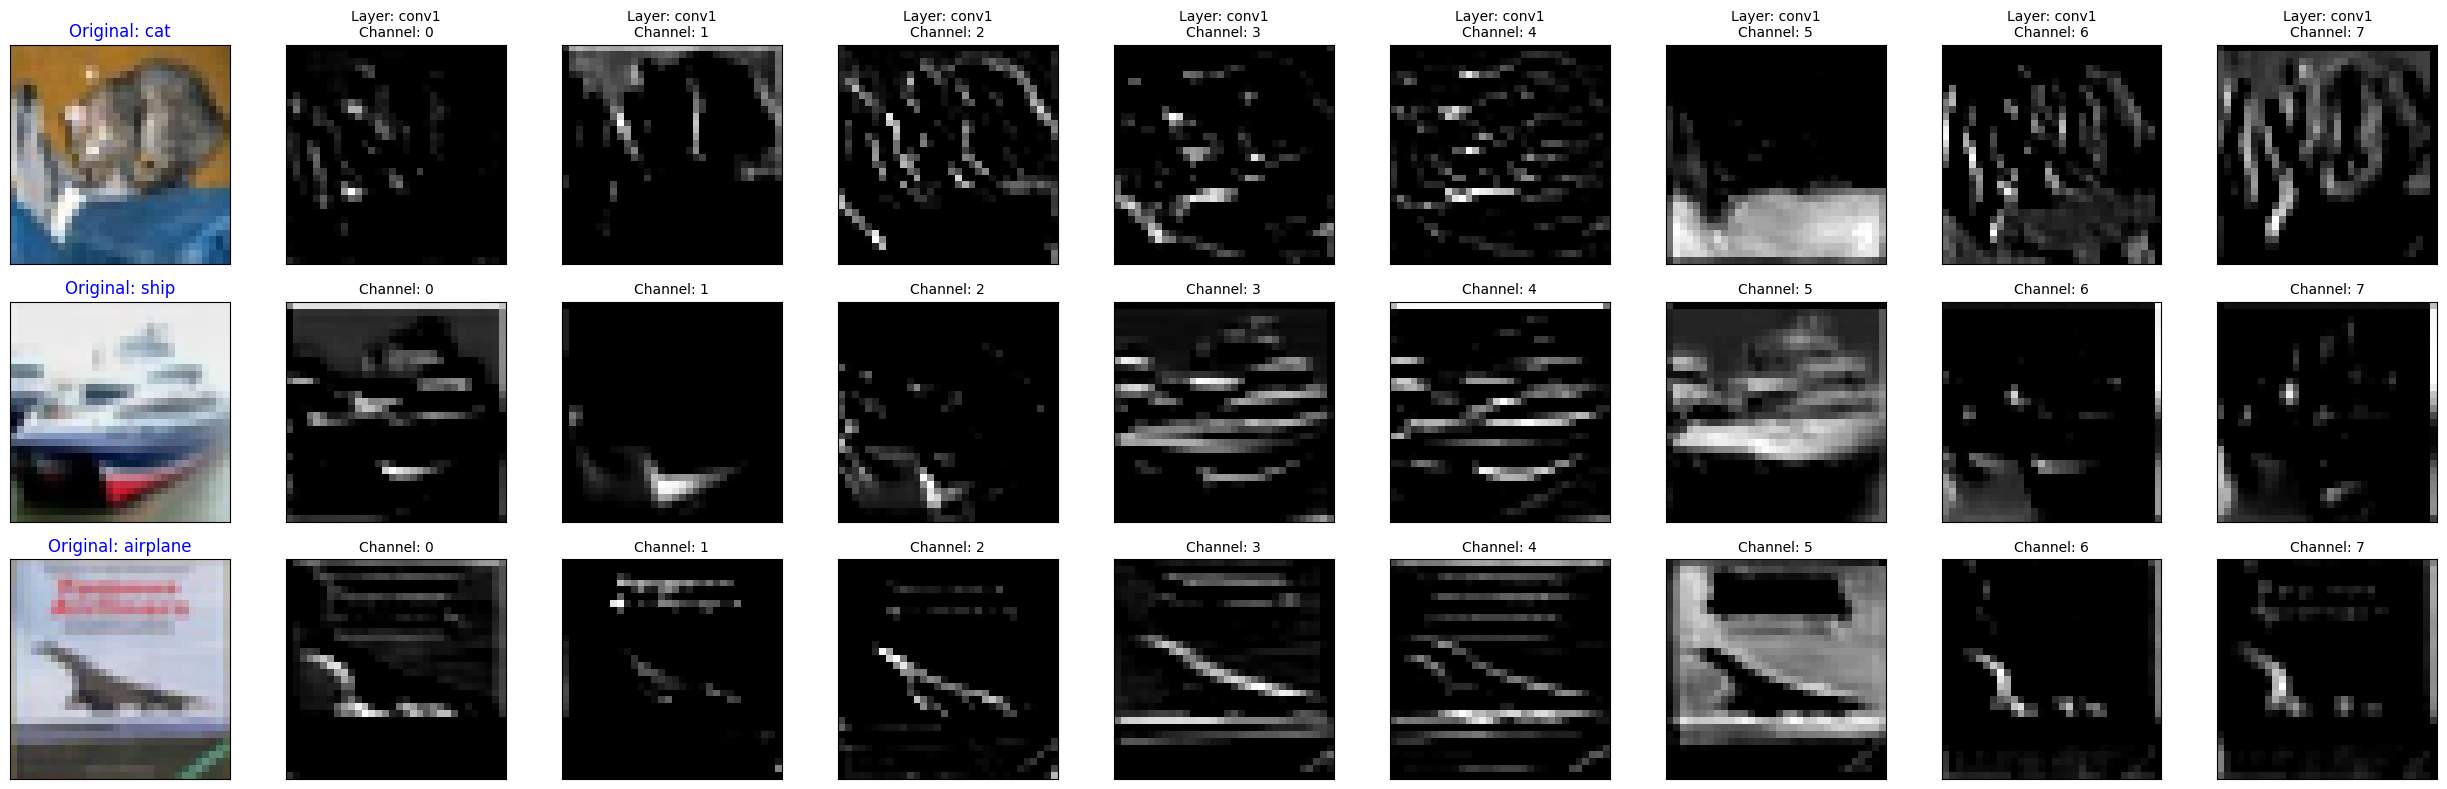

In [19]:
# set the display figure size.
fig = plt.figure(figsize=(25, 8))

for image_counter in range(3):

    # Cells with this ID will display the original image.
    idx_orig = image_counter * 9 + 1
    
    ax = fig.add_subplot(3, 9, idx_orig, xticks=[], yticks=[])
    
    img_np = selected_images[image_counter].numpy().transpose((1, 2, 0)) / 2 + 0.5
    plt.imshow(img_np)
    ax.set_title(f"Original: {classes[selected_labels[image_counter]]}", color="blue")

    with torch.no_grad():
        output = model_adam.conv1(selected_images[image_counter].unsqueeze(0))
        feature_maps = torch.nn.functional.relu(output)

    for feature_counter in range(8):
        idx_map = image_counter * 9 + feature_counter + 2
        ax = fig.add_subplot(3, 9, idx_map, xticks=[], yticks=[])

        plt.imshow(feature_maps[0, feature_counter].numpy(), cmap='gray')

        if image_counter == 0:
            ax.set_title(f"Layer: conv1\nChannel: {feature_counter}", fontsize=10)
        else:
            ax.set_title(f"Channel: {feature_counter}", fontsize=10)

plt.tight_layout()
plt.show()

This is very hard for me to explain this, but my personal opinion, the model is tracking mostly with shapes and colors based on the different layers. I like the channel 7 mostly, because that mostly grasps the image's shape. I could see the shape of the airplane very well with this; meanwhile, channel 3 mostly tells the details of the object. Also I could see that channel 4 takes the red color vividly and channel 5 takes the blue color the most.

Based on the given results, filters detect the feature, like edges and feature, of the object from the differnet perspectives to maximize the extraction of the feature.

# Part B: Maximally Activating Images for Selected Filters
- Choose one convolutional layer (early or middle layer).

I chose conv2 with layer 3, 5, 7, because I thought those are easier to detect the similarities based on the information from Part A. 

In [20]:
selected_filters = [3, 5, 7]

top_activations = []
top_activations = {f: [] for f in selected_filters}

with torch.no_grad():
    for images, labels in test_loader:
        x = torch.nn.functional.relu(model_adam.conv1(images))
        x = model_adam.pool(x)
        features = torch.nn.functional.relu(model_adam.conv2(x))
        
        for i in range(images.size(0)):
            for f in selected_filters:
                score = features[i, f].max().item()
                top_activations[f].append((score, images[i]))
        
        if len(top_activations[selected_filters[0]]) >= 1000:
            break


For each filter:
- Find the top 5 test images that produce the highest activation.
    - Clarification on “activation”: Each convolutional filter produces a 2D
feature map (after ReLU), with one activation value per spatial location.
To measure how strongly a filter responds to an image, this 2D feature
map must be reduced to a single scalar value. You may define the
activation of a filter for an image as either:
      - the maximum value in the feature map (strongest local response),
      - or the mean value of the feature map (overall response strength).
    - You must clearly state which definition you use.
- Visualize these images.

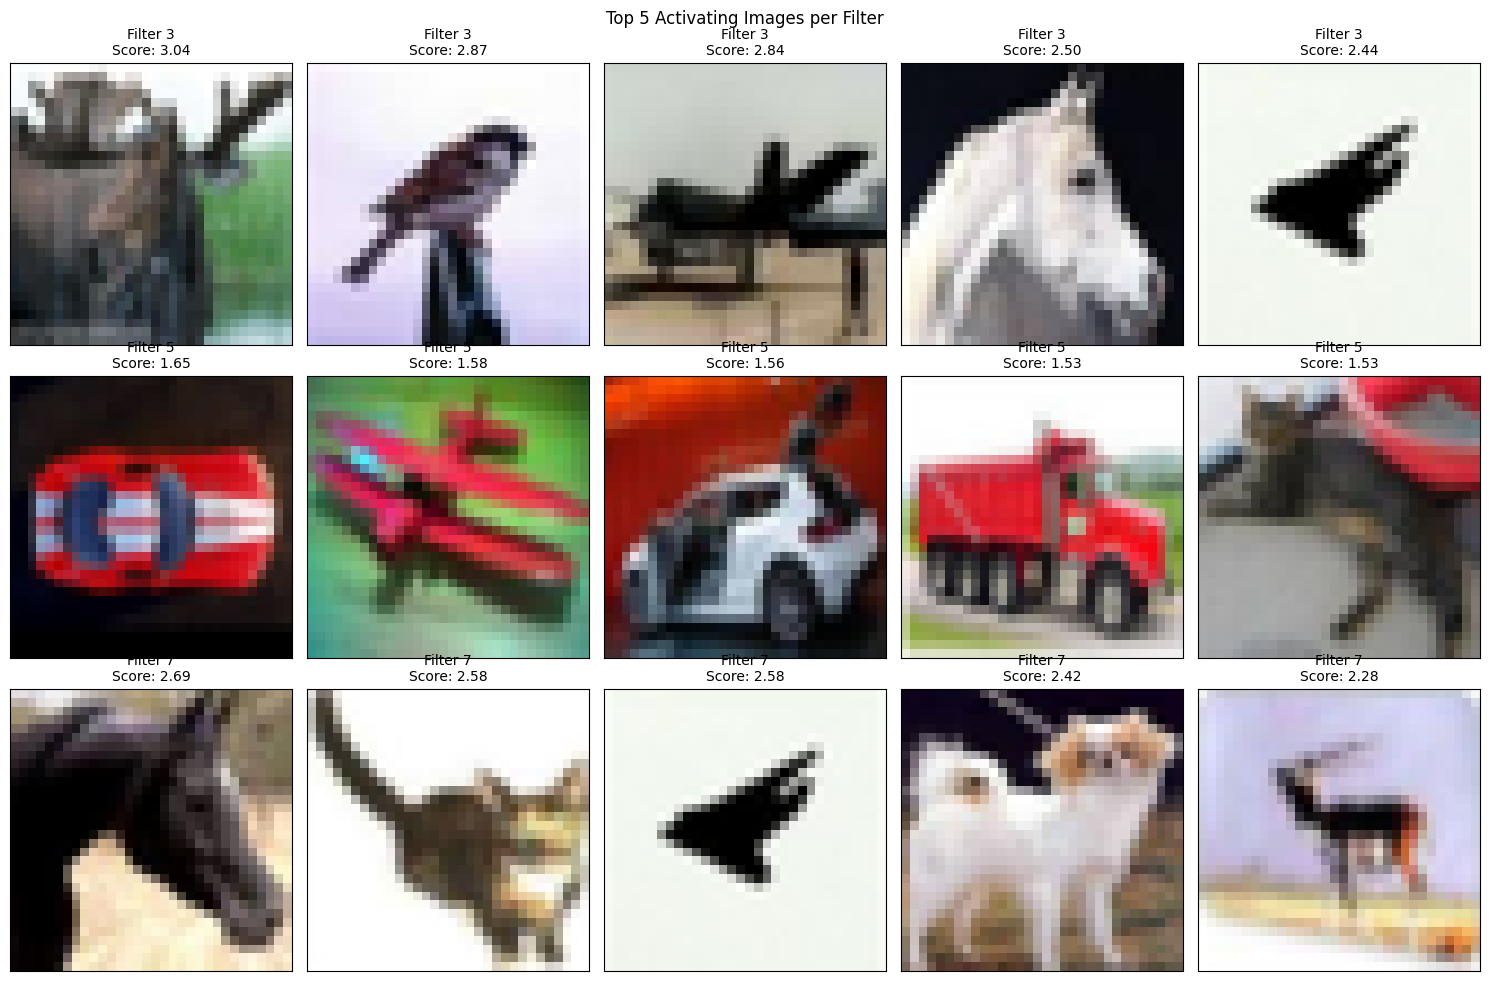

In [22]:
def get_score(item):
    """Gets the first item's score"""
    return item[0]

for f in selected_filters:
    top_activations[f].sort(key=get_score, reverse=True)
    top_activations[f] = top_activations[f][:5]


fig = plt.figure(figsize=(15, 10))
fig.suptitle(f"Top 5 Activating Images per Filter")

for counter, f_idx in enumerate(selected_filters):
    
    top_5_list = top_activations[f_idx]
    
    for feature_counter in range(5):
        ax_idx = counter * 5 + feature_counter + 1
        ax = fig.add_subplot(3, 5, ax_idx, xticks=[], yticks=[])

        # Extract score and image
        score, img_tensor = top_5_list[feature_counter]

        # image process for display.
        img_np = img_tensor.numpy().transpose((1, 2, 0)) / 2 + 0.5
        
        plt.imshow(img_np)
        
        ax.set_title(f"Filter {f_idx}\nScore: {score:.2f}", fontsize=10)

plt.tight_layout()
plt.show()

The answer changes as we create a new model, so I will explain for this run. (The filter chooses the new top 5 every time when we create a new model every time).

I have used Gemini to produce the template code to extract the image out of the filter.

Based on the given results, filters detect the feature, like edges and feature, of the object from the differnet perspectives to maximize the extraction of the feature.

Expected from the Part A's result filter 3, 5 and 7 has common pattern when it comes to choosing the image.
- Filter 3 detectes the shape or the type of the object in mainly with the context of flying object, which usually has a plain background because they are in the sky.
- Suprisingly, Filter 5 takes in the Red color, which was complete opposite with my result. What my guess to this result is that this filter is detecting how much "red" based on the blue color from the surrounding image, which might be helpful for detecting if the given object is a flyable or not.
- Filter 7 was little bit hard to deduce on what it was detecting, but my guess is it is detecting the pointiness of the object, like does the given object has a legs/tail or not.